<a href="https://colab.research.google.com/github/Lusllou/Machinelearning/blob/main/_deepfake_ml2025_2026_ipynb.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Створення діпфейку

Перед початком роботи, оберіть тип процесора - **Графічний процесор Т4**

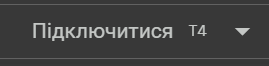

##1. Клонуємо репозиторій та встановлюємо необхідні бібліотеки

In [ ]:
!git clone https://github.com/KsiuTretyakova/first-order-model.git
%cd first-order-model
!pip install ffmpeg-python
!pip install imageio
!pip install imageio-ffmpeg

Cloning into 'first-order-model'...
remote: Enumerating objects: 391, done.
remote: Counting objects: 100% (50/50), done.
remote: Compressing objects: 100% (16/16), done.
remote: Total 391 (delta 36), reused 34 (delta 34), pack-reused 341 (from 2)
Receiving objects: 100% (391/391), 72.19 MiB | 22.24 MiB/s, done.
Resolving deltas: 100% (202/202), done.
Updating files: 100% (48/48), done.
/content/first-order-model


## 2. Завантажуємо файли для створення deapfake

Вам необхідно перейти за посиланням: https://www.google.com/url?q=https%3A%2F%2Fdrive.google.com%2Fdrive%2Ffolders%2F1GdbnZ0M0GItLaUgYzlz-l_wlajYHSww4

Залогінитись у свій Google Account і створити ярлик на цю зашарену папку:

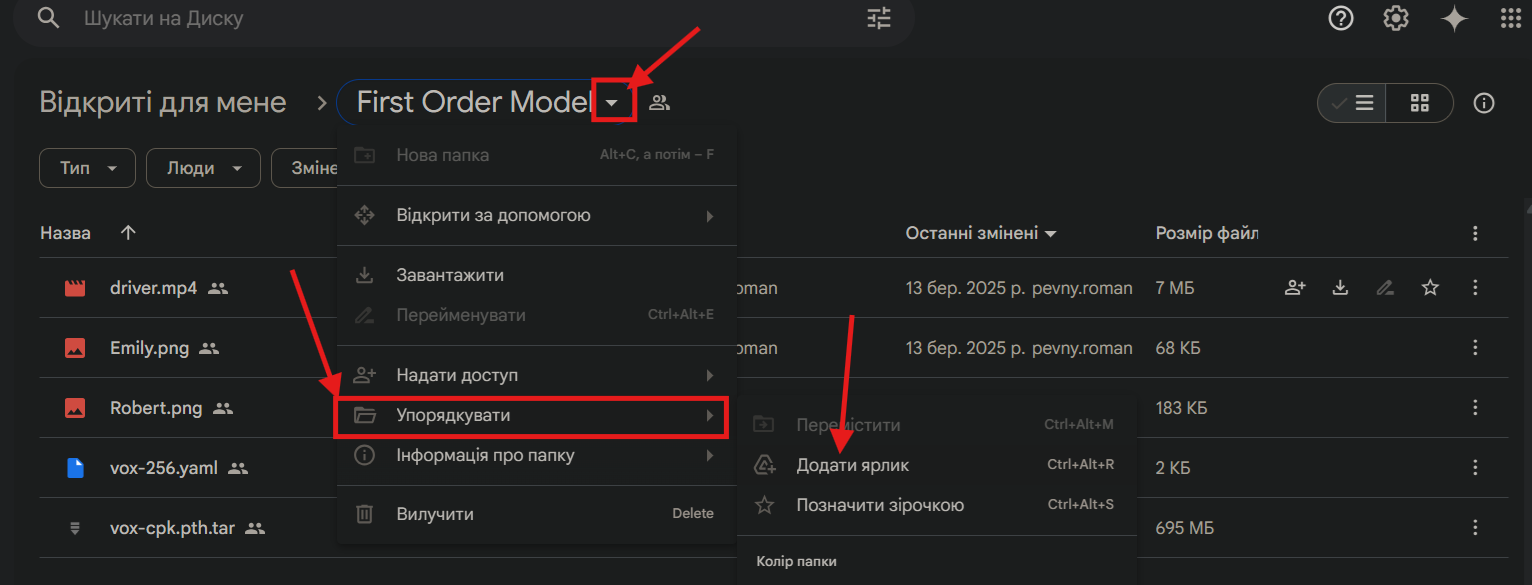

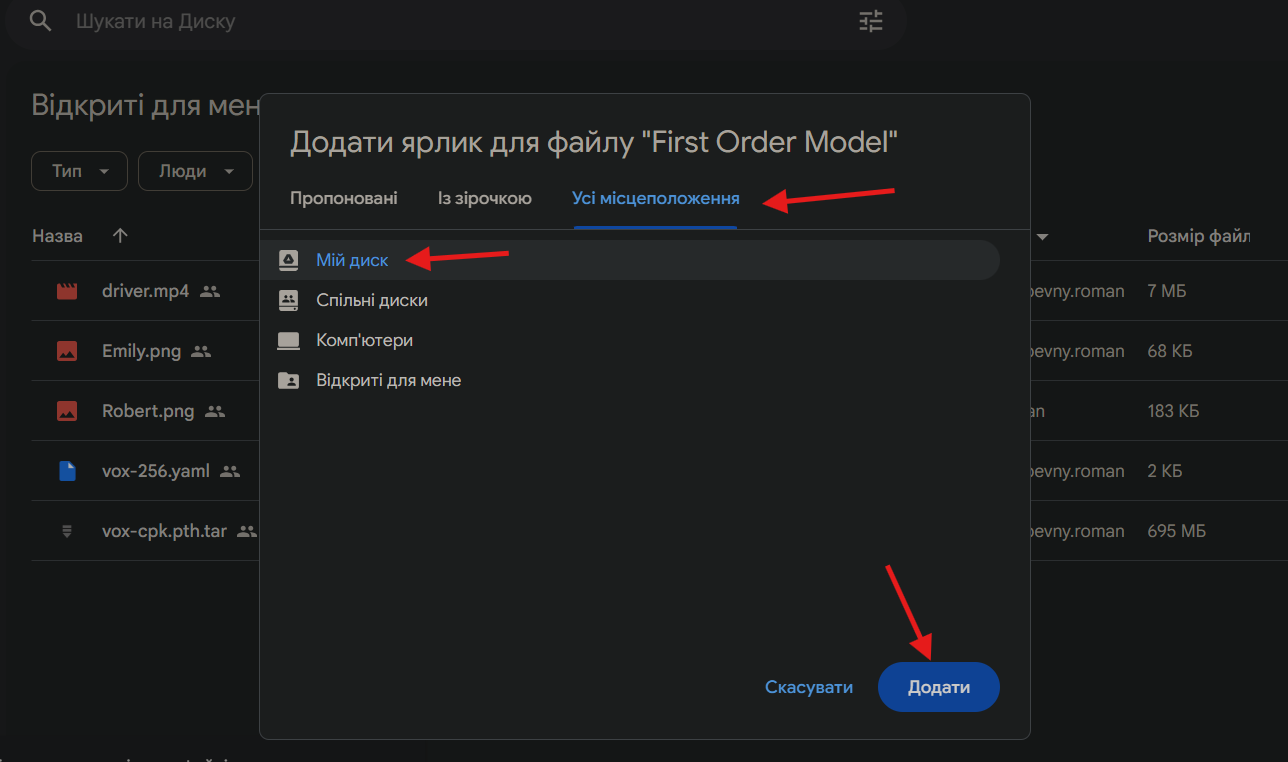

В результаті цих дій на вашому Google Drive з'явиться ярлик (посилання) на розшарену папку і ми зможемо повноцінно з нею працювати у Colab.
### Які файли тут присутні?
*   `vox-cpk.pth.tar` - це головний файл з моделлю
*   `vox-256.yaml` - файл конфігурації (налаштування) для коректної роботи моделі
*   `Emily.png`,`Robert.png` - це тестові зображення, для яких ми будемо створювати анімацію
*   `driver.mp4` - це відео з різними гримасами, на базі якого наше зображення буде "оживати"

## 3. Підключаємо свій Google Drive

На цьому етапі під час виконання відкриється окреме віконце, де необхідно буде вибрати свій Google Account для доступу до Google Drive, у якому ви вище створили лінку на папку з файлами.

In [ ]:
from google.colab import drive
drive.mount('/content/gdrive', force_remount=True)

Mounted at /content/gdrive


## 4. Завантажуємо модель та конфігурацію для неї

In [ ]:
from demo import load_checkpoints
#root_path = '/content/gdrive/My Drive/First Order Model/'  # Ярлик у My Drive
root_path = '/content/gdrive/My Drive/Colab Notebooks/First Order Model/'

generator, kp_detector = load_checkpoints(config_path=root_path+'vox-256.yaml',
                                          checkpoint_path=root_path+'vox-cpk.pth.tar')


/content/first-order-model/modules/dense_motion.py:71: SyntaxWarning: invalid escape sequence '\h'
  Eq 7. in the paper \hat{T}_{s<-d}(z)


FileNotFoundError: [Errno 2] No such file or directory: '/content/gdrive/My Drive/Colab Notebooks/First Order Model/vox-256.yaml'

##5. Задаємо шлях до тестового зображення з обличчям та навчального відео для моделі

In [ ]:
#@title 5. Задаємо шлях до тестового зображення з обличчям та навчального відео для моделі
face_path = 'Robert.png' #@param {type:"string"}
driver_path = 'driver.mp4' #@param {type:"string"}

## 6. Створюємо функцію для відображення анімованого результату

In [ ]:
#@title 5. Задаємо шлях до тестового зображення з обличчям та навчального відео для моделі
face_path = 'Robert.png' #@param {type:"string"}
driver_path = 'driver.mp4' #@param {type:"string"}import numpy as np
import matplotlib.pyplot as plt
import matplotlib.animation as animation

import warnings
warnings.filterwarnings("ignore")   # ігноруємо усі попередження

def display(source, driving, generated=None):
  # створюємо область для відображення результату
  fig = plt.figure(figsize=(8 + 4 * (generated is not None), 6))  # 12x6

  ims = []
  # розміщуємо початкове зображення, навчальне відео та результуючу анімацію поряд
  for i in range(len(driving)):
      cols = [source]
      cols.append(driving[i])
      if generated is not None:
          cols.append(generated[i])
      im = plt.imshow(np.concatenate(cols, axis=1), animated=True)
      plt.axis('off')  # вимикаємо відображення вісі X,Y
      ims.append([im])

  # створення анімації
  ani = animation.ArtistAnimation(fig, ims, interval=50, repeat_delay=1000)
  plt.close()
  return ani

## 7. Створюємо анімацію тестового зображення (deepfake)

In [ ]:
import imageio
from demo import make_animation
from skimage import img_as_ubyte
from skimage.transform import resize
from IPython.display import HTML

source_image = imageio.imread(root_path + face_path)
reader = imageio.get_reader(root_path + driver_path)

fps = reader.get_meta_data()['fps']

# розіб'ємо навчальне відео на окремі кадри і збережемо у масив
driving_video = []
try:
  for im in reader:
    driving_video.append(im)
except RuntimeError:
  pass
except Exception as e:
  print(f"ERROR: {e}")
reader.close()

# конвертуємо тестове зображення та навчальне відео до однакових розмірів 256 х 256
source_image = resize(source_image, (256, 256))[..., :3]
driving_video = [resize(frame, (256, 256))[..., :3] for frame in driving_video]

# dv = []
# for frame in driving_video:
#   im = resize(frame, (256, 256))[..., :3]
#   dv.append(im)

# driving_video = copy(dv)

# створюємо анімацію
predictions = make_animation(
    source_image,
    driving_video,
    generator,
    kp_detector,
    relative=True,
    adapt_movement_scale=True)

# зберігаємо результуюче відео deepfake
imageio.mimsave('../output.mp4', [img_as_ubyte(frame) for frame in predictions])

HTML(display(source_image, driving_video, predictions).to_html5_video())

## 8. Скачуємо отримане відео

In [ ]:
from google.colab import files
files.download("/content/output.mp4")